In [ ]:
#cnn
import os
import glob
import pandas as pd
import numpy as np
from itertools import product
from huggingface_hub import HfApi, snapshot_download
from google.colab import userdata

# ==========================================
# 1. Hugging Face 配置 (替代 Drive 挂载)
# ==========================================
HF_TOKEN = userdata.get('HF_TOKEN') # 请确保 Colab Secret 中有 HF_TOKEN
REPO_ID = "JONESMITH007/DFL"        # 你的仓库 ID
LOCAL_ROOT = "./DFL_CNN_Results"    # 本地缓存路径a

# 注意：根据你之前的上传逻辑，结果存储在仓库的这个子文件夹下
REPO_SUBFOLDER = "FL_Experiments/cnn_Results_2026_inew"
SAVE_DIR = os.path.join(LOCAL_ROOT, REPO_SUBFOLDER)

os.makedirs(SAVE_DIR, exist_ok=True)

# --- 同步远程数据到本地 ---
print("🔄 正在从 Hugging Face 同步数据...")
snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    local_dir=LOCAL_ROOT,
    allow_patterns=["**/Final_CNN*.csv"], # 下载所有 CNN 相关的 CSV
    token=HF_TOKEN
)

# ==========================================
# 2. 实验参数配置 (用于进度扫描)
# ==========================================
SEEDS = [1, 2, 3]
# 🌟 修改点 1：将 MAB 拆分为两种拓扑感知状态
MECHANISM_LIST = ['FedAvg', 'MAB(TOPY AWARE)', 'MAB(RANDOM TOPY)', 'FLAME', 'CosL2', 'TrimmedMean', 'Krum']
MAL_RATIOS = [0.1, 0.2, 0.3]
TOPO_TYPES = ['random_regular', 'scale_free']
DEFENSE_RATIOS = [0.2]

# ==========================================
# 3. 进度扫描逻辑
# ==========================================
all_combinations = list(product(TOPO_TYPES, MAL_RATIOS, DEFENSE_RATIOS, SEEDS, MECHANISM_LIST))
tasks_df = pd.DataFrame(all_combinations, columns=['Topology', 'Mal_Ratio', 'Def_Ratio', 'Seed', 'Mechanism'])

def check_file(row):
    topo = row['Topology']
    mr = row['Mal_Ratio']
    dr = row['Def_Ratio']
    seed = row['Seed']
    mech = row['Mechanism']

    # 🌟 修改点 2：根据不同的 MAB 类型匹配相应的文件名
    if mech == 'MAB(RANDOM TOPY)':
        filename = f"Final_CNN_{topo}_MR{mr}_DR{dr}_MAB_seed{seed}_placement_random.csv"
    elif mech == 'MAB(TOPY AWARE)':
        filename = f"Final_CNN_{topo}_MR{mr}_DR{dr}_MAB_seed{seed}.csv"
    else:
        filename = f"Final_CNN_{topo}_MR{mr}_DR{dr}_{mech}_seed{seed}.csv"

    return os.path.exists(os.path.join(SAVE_DIR, filename))

print("🔍 正在分析任务完成度...")
tasks_df['Is_Completed'] = tasks_df.apply(check_file, axis=1)

# 生成进度表
progress_summary = tasks_df.groupby(['Mechanism', 'Mal_Ratio']).agg(
    Completed=('Is_Completed', 'sum'),
    Total=('Is_Completed', 'size')
).reset_index()

progress_summary['Status_Bar'] = progress_summary.apply(lambda x: f"{int(x['Completed'])}/{int(x['Total'])}", axis=1)

print("\n📊 实验进度矩阵 (按机制与恶意比例):")
pivot_progress = progress_summary.pivot(index='Mechanism', columns='Mal_Ratio', values='Status_Bar')
print(pivot_progress)
# ==========================================
# 4. 数据加载与核心分析 (完美双线加载法)
# ==========================================
search_pattern = os.path.join(SAVE_DIR, "Final_CNN*.csv")
all_files = glob.glob(search_pattern)

if not all_files:
    print("\n❌ 警告：未发现任何已完成的实验文件。")
    df_results = pd.DataFrame()
else:
    print(f"\n✅ 发现 {len(all_files)} 个实验结果文件，正在分类加载...")
    list_df = []

    for f in all_files:
        temp_df = pd.read_csv(f)

        # 路线 A：如果是 RANDOM TOPY 文件
        if "placement_random" in os.path.basename(f):
            temp_df['mechanism'] = 'MAB(RANDOM TOPY)'
            list_df.append(temp_df)

        # 路线 B：如果不包含 RANDOM TOPY
        else:
            # 原本的机制是什么就是什么 (Krum, FedAvg, FLAME 等)
            # 但如果它原本叫 'MAB'，我们给它重命名为 'MAB(TOPY AWARE)' 以作区分
            temp_df['mechanism'] = temp_df['mechanism'].replace({'MAB': 'MAB(TOPY AWARE)'})
            list_df.append(temp_df)

    # 合并所有数据
    df_results = pd.concat(list_df, ignore_index=True)

    # --- 数据清洗与分析 ---
    df_results['Role'] = df_results['node_type'].apply(lambda x: 'Malicious' if x == 'MAL' else 'Benign')
    df_benign = df_results[df_results['Role'] == 'Benign']

    # 透视表对比
    benign_comparison = df_benign.pivot_table(
        index='mechanism',
        columns='malicious_ratio',
        values=['final_acc', 'final_asr'],
        aggfunc='mean'
    )

    print("\n📈 良性节点平均表现对比 (ASR/ACC):")
    print(benign_comparison)

# ==========================================
# 5. 总体统计
# ==========================================
total_tasks = len(tasks_df)
completed_tasks = tasks_df['Is_Completed'].sum()
print(f"\n{'='*40}")
print(f"🏆 总体完成度: {(completed_tasks/total_tasks*100):.1f}%")
print(f"已完成: {completed_tasks} | 剩余: {total_tasks - completed_tasks}")
print(f"{'='*40}")

🔄 正在从 Hugging Face 同步数据...


Fetching ... files: 0it [00:00, ?it/s]

🔍 正在分析任务完成度...

📊 实验进度矩阵 (按机制与恶意比例):
Mal_Ratio        0.1000 0.2000 0.3000
Mechanism                            
CosL2               6/6    6/6    6/6
FLAME               6/6    6/6    6/6
FedAvg              6/6    6/6    6/6
Krum                6/6    6/6    6/6
MAB(RANDOM TOPY)    6/6    6/6    6/6
MAB(TOPY AWARE)     6/6    6/6    6/6
TrimmedMean         6/6    6/6    6/6

✅ 发现 126 个实验结果文件，正在分类加载...

📈 良性节点平均表现对比 (ASR/ACC):
                 final_acc                 final_asr                
malicious_ratio     0.1000  0.2000  0.3000    0.1000  0.2000  0.3000
mechanism                                                           
CosL2              43.7207 54.4046 63.3072   13.5473 12.2662 17.3793
FLAME              73.2809 72.7589 73.1327   14.2922 13.4097 12.2299
FedAvg             84.2462 81.5636 79.8482   35.9115 52.5093 63.1315
Krum               84.2434 79.4280 75.3876   36.5597 48.0949 69.0345
MAB(RANDOM TOPY)   85.4043 84.8178 84.9968    4.8951  5.7708 11.9286
MAB(TOPY AWARE) 

In [ ]:
# ==========================================
#  生成 LaTeX 表格 (采用宏观平均 Macro-average)
# ==========================================
print("\n📝 正在基于宏观平均 (Macro-average) 生成 LaTeX 表格代码...\n")

# 1. 筛选特定拓扑与良性节点
df_results2 = df_results[df_results['topology'] == 'scale_free'].copy()#'scale_free' 'random_regular'
df_results2 = df_results2[df_results2['malicious_ratio'] != 0.4].copy()
df_benign = df_results2[df_results2['Role'] == 'Benign'].copy()

# 2. 🌟 宏观平均第一步：先求每个 Seed (单次实验) 内良性节点的平均值
trial_means = df_benign.groupby(
    ['mechanism', 'malicious_ratio', 'seed']
)[['final_acc', 'final_asr']].mean().reset_index()

# 3. 🌟 宏观平均第二步：跨 Seed 计算整体的均值 (mean) 和标准差 (std)
stats = trial_means.groupby(
    ['mechanism', 'malicious_ratio']
)[['final_acc', 'final_asr']].agg(['mean', 'std']).reset_index()

# 4. 格式化为期刊标准的 "Mean (Std)" 格式
def format_mean_std(row, metric):
    m = row[(metric, 'mean')]
    s = row[(metric, 'std')]
    return f"{m:.2f} ({s:.2f})"

stats['ACC'] = stats.apply(lambda r: format_mean_std(r, 'final_acc'), axis=1)
stats['ASR'] = stats.apply(lambda r: format_mean_std(r, 'final_asr'), axis=1)

# 5. 整理列名并生成透视表
clean_stats = stats[['mechanism', 'malicious_ratio', 'ACC', 'ASR']].copy()
latex_table = clean_stats.pivot(index='mechanism', columns='malicious_ratio', values=['ACC', 'ASR'])

# 6. 交换列的层级，使 malicious_ratio 在上，ACC/ASR 在下，并排序
latex_table = latex_table.swaplevel(0, 1, axis=1).sort_index(axis=1, level=0)

# 如果包含 0.4 的恶意比例且你不需要展示，取消下方注释将其过滤掉
# if 0.4 in latex_table.columns.levels[0]:
#     latex_table = latex_table.drop(columns=[0.4], level=0)

# 7. 强制指定行的排列顺序 (将 MAB 对照组放一起)
# ... [前面的步骤 1-3 保持不变] ...

# 4. 🌟 修改点：格式化为百分制 "Mean (Std)"
def format_mean_std_percent(row, metric):
    # 将均值和标准差都乘以 100
    m = row[(metric, 'mean')]
    s = row[(metric, 'std')]

    # 使用 :05.2f 强制要求总宽度为5位，不足处补0
    # 这样 8.12 会变成 08.12，而 12.34 依然是 12.34
    return f"{m:05.2f} ({s:05.2f})"

# 使用新的百分制格式化函数
stats['ACC (%)'] = stats.apply(lambda r: format_mean_std_percent(r, 'final_acc'), axis=1)
stats['ASR (%)'] = stats.apply(lambda r: format_mean_std_percent(r, 'final_asr'), axis=1)

# 5. 整理列名并生成透视表 (注意列名同步修改为 ACC (%) 和 ASR (%))
clean_stats = stats[['mechanism', 'malicious_ratio', 'ACC (%)', 'ASR (%)']].copy()
latex_table = clean_stats.pivot(index='mechanism', columns='malicious_ratio', values=['ACC (%)', 'ASR (%)'])

# 6. 交换列层级并排序
latex_table = latex_table.swaplevel(0, 1, axis=1).sort_index(axis=1, level=0)

# 7. 强制指定行的排列顺序 (修复了你代码里缺少的逗号)
custom_order = [
    'FedAvg',
    'Krum',
    'TrimmedMean',
    'CosL2',
    'FLAME',
    'MAB(RANDOM TOPY)', # 👈 这里原先缺个逗号
    'MAB(TOPY AWARE)',
]
# ... [后续 reindex 和导出逻辑相同] ...
existing_order = [m for m in custom_order if m in latex_table.index]
other_mechs = [m for m in latex_table.index if m not in custom_order]
final_order = existing_order + other_mechs

latex_table = latex_table.reindex(final_order)

# 8. 导出 LaTeX 代码
try:
    # 适配新版 Pandas (使用 Styler)
    latex_output = latex_table.style.format(escape="latex").to_latex(
        hrules=True,
        multicol_align="c",
        caption="Macro-Averaged Comparative Performance Summary (Random Regular)",
        label="tab:macro_results_random_regular"
    )
except AttributeError:
    # 适配老版本 Pandas
    latex_output = latex_table.to_latex(
        multicolumn=True,
        multicolumn_format='c',
        booktabs=True,
        escape=False,
        caption="Macro-Averaged Comparative Performance Summary (Random Regular)",
        label="tab:macro_results_random_regular"
    )

print(latex_output)


📝 正在基于宏观平均 (Macro-average) 生成 LaTeX 表格代码...

\begin{table}
\caption{Macro-Averaged Comparative Performance Summary (Random Regular)}
\label{tab:macro_results_random_regular}
\begin{tabular}{lllllll}
\toprule
malicious_ratio & \multicolumn{2}{c}{0.100000} & \multicolumn{2}{c}{0.200000} & \multicolumn{2}{c}{0.300000} \\
 & ACC (%) & ASR (%) & ACC (%) & ASR (%) & ACC (%) & ASR (%) \\
mechanism &  &  &  &  &  &  \\
\midrule
FedAvg & 84.00 (00.65) & 24.12 (16.53) & 82.14 (01.21) & 32.28 (20.04) & 80.27 (01.34) & 53.27 (13.19) \\
Krum & 84.15 (01.01) & 23.92 (16.89) & 81.25 (02.49) & 26.57 (16.10) & 75.76 (02.60) & 61.01 (24.02) \\
TrimmedMean & 83.97 (00.86) & 14.76 (11.08) & 82.58 (02.02) & 08.63 (08.66) & 80.05 (02.85) & 17.81 (09.82) \\
CosL2 & 52.17 (04.26) & 11.91 (05.52) & 55.59 (03.80) & 06.41 (00.85) & 65.52 (01.69) & 16.80 (04.16) \\
FLAME & 73.24 (00.15) & 12.11 (02.94) & 72.89 (00.46) & 11.24 (03.22) & 73.49 (01.01) & 10.48 (02.11) \\
MAB(RANDOM TOPY) & 84.84 (01.26) & 05.67 (04


⏱️ 正在生成耗时分析柱状图...


/tmp/ipykernel_606/2607090887.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


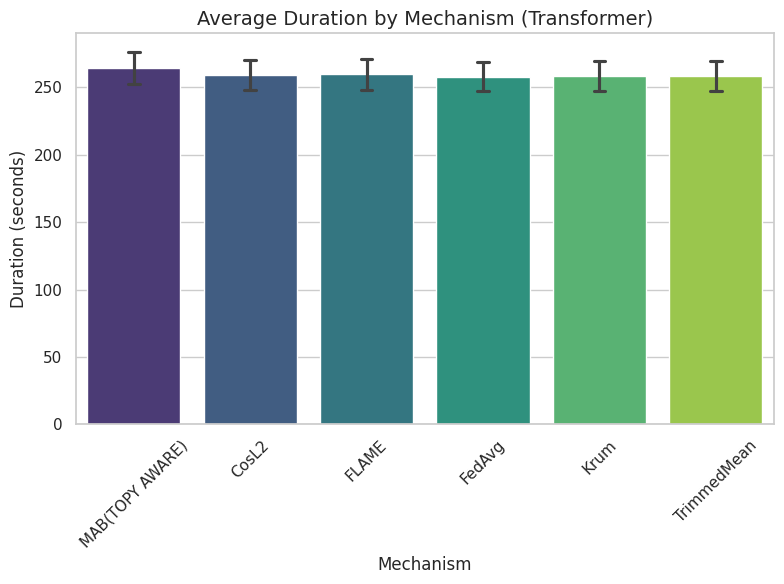

In [ ]:
# ==========================================
# 6. Duration (耗时) 分析与绘图 (固定顺序版)
# ==========================================
# --- 核心修改：复制时直接过滤掉 'MAB(RANDOM TOPY)' ---
df_results2 = df_results[df_results['mechanism'] != 'MAB(RANDOM TOPY)'].copy()

if not df_results2.empty and 'duration_sec' in df_results2.columns:
    print("\n⏱️ 正在生成耗时分析柱状图...")

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 6))

    # --- 获取所有唯一的 mechanism 名称（此时已经没有 MAB(RANDOM TOPY) 了） ---
    all_mechanisms = df_results2['mechanism'].unique().tolist()

    # 定义你想要的顺序：先放 'MAB(TOPY AWARE)'，再放剩下的其他项（按字母排序）
    target_first = 'MAB(TOPY AWARE)'

    if target_first in all_mechanisms:
        # 创建新列表：[target_first] + [除target_first以外的其他项]
        custom_order = [target_first] + sorted([m for m in all_mechanisms if m != target_first])
    else:
        # 如果没找到完全匹配的 'MAB(TOPY AWARE)'，则使用默认排序
        custom_order = sorted(all_mechanisms)

    # 1. 柱状图 (传入 order 参数)
    sns.barplot(
        data=df_results2,
        x='mechanism',
        y='duration_sec',
        order=custom_order,  # 👈 强制固定顺序
        palette='viridis',
        capsize=.1,
        errorbar='sd'
    )

    plt.title('Average Duration by Mechanism (CNN)', fontsize=14)
    plt.xlabel('Mechanism', fontsize=12)
    plt.ylabel('Duration (seconds)', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show() # 或者 plt.savefig(...)


🔍 开始分析 FedAvg 的 final_asr 和 theo_intensity 相关性 (Kendall Tau) - 包含所有节点...
✅ 发现 18 个 FedAvg 文件，正在提取所有节点数据...

📈 各个 FedAvg 文件的 Kendall Tau 相关性分析结果 (含 P 值):
                                                 File       Topology  Mal_Ratio  Seed  Nodes_Count  Kendall_Tau  P_Value Is_Significant
Final_CNN_random_regular_MR0.2_DR0.2_FedAvg_seed3.csv random_regular     0.2000     3           20       0.5820   0.0004            Yes
    Final_CNN_scale_free_MR0.1_DR0.2_FedAvg_seed3.csv     scale_free     0.1000     3           20       0.4278   0.0092            Yes
Final_CNN_random_regular_MR0.2_DR0.2_FedAvg_seed2.csv random_regular     0.2000     2           20       0.8526   0.0000            Yes
    Final_CNN_scale_free_MR0.2_DR0.2_FedAvg_seed2.csv     scale_free     0.2000     2           20       0.7143   0.0000            Yes
Final_CNN_random_regular_MR0.3_DR0.2_FedAvg_seed3.csv random_regular     0.3000     3           20       0.5820   0.0004            Yes
Final_CNN_random_regular_MR0.1

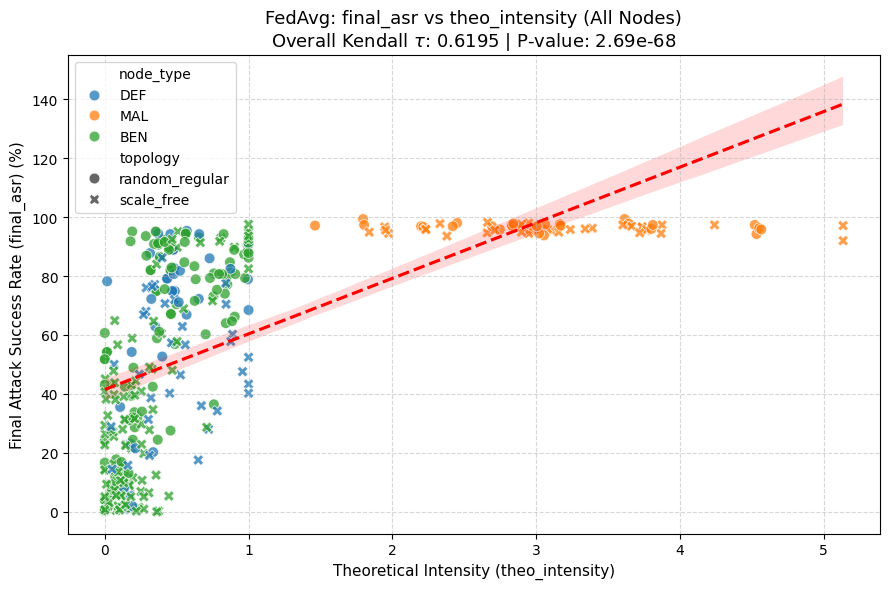

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kendalltau  # 导入用于计算 tau 和 p_value 的函数

# ==========================================
# 6. 分析 FedAvg 文件的 final_asr 与 theo_intensity 的相关性 (Kendall Tau)
# ==========================================
print(f"\n{'='*40}")
print("🔍 开始分析 FedAvg 的 final_asr 和 theo_intensity 相关性 (Kendall Tau) - 包含所有节点...")
print(f"{'='*40}")

# 匹配所有包含 FedAvg 的文件
fedavg_pattern = os.path.join(SAVE_DIR, "Final_CNN*FedAvg*.csv")
fedavg_files = glob.glob(fedavg_pattern)

if not fedavg_files:
    print("\n❌ 未找到任何 FedAvg 相关的 CSV 文件进行相关性分析。")
else:
    print(f"✅ 发现 {len(fedavg_files)} 个 FedAvg 文件，正在提取所有节点数据...\n")

    correlation_results = []
    all_fedavg_nodes = [] # 保存所有文件的数据以供后续汇总绘图

    for f in fedavg_files:
        df = pd.read_csv(f)

        # 1. 保留所有节点（不过滤 MAL 节点）
        df_target = df.copy()

        # 2. 确保目标列为数值类型 (防止字符导致报错)
        df_target['final_asr'] = pd.to_numeric(df_target['final_asr'], errors='coerce')
        df_target['theo_intensity'] = pd.to_numeric(df_target['theo_intensity'], errors='coerce')

        # 3. 去除可能存在的空值
        df_target = df_target.dropna(subset=['final_asr', 'theo_intensity'])

        if len(df_target) > 1: # 至少需要2个点才能算相关性
            # 4. 提取该文件对应的实验参数
            topo = df_target['topology'].iloc[0] if 'topology' in df_target.columns else "Unknown"
            mr = df_target['malicious_ratio'].iloc[0] if 'malicious_ratio' in df_target.columns else "Unknown"
            seed = df_target['seed'].iloc[0] if 'seed' in df_target.columns else "Unknown"

            # 5. 使用 scipy 计算 Kendall Tau 系数和 p 值
            tau, p_value = kendalltau(df_target['final_asr'], df_target['theo_intensity'])

            # 6. 记录结果
            correlation_results.append({
                'File': os.path.basename(f),
                'Topology': topo,
                'Mal_Ratio': mr,
                'Seed': seed,
                'Nodes_Count': len(df_target),
                'Kendall_Tau': tau,
                'P_Value': p_value,
                'Is_Significant': 'Yes' if p_value < 0.05 else 'No'
            })

            all_fedavg_nodes.append(df_target)

    # 7. 显示各个文件单独的相关性结果
    if correlation_results:
        corr_df = pd.DataFrame(correlation_results)
        print("📈 各个 FedAvg 文件的 Kendall Tau 相关性分析结果 (含 P 值):")
        # 优化显示：让数值保留小数点后几位更好看
        pd.options.display.float_format = '{:.4f}'.format
        print(corr_df.to_string(index=False))

        # 8. 综合计算与绘图分析
        combined_df = pd.concat(all_fedavg_nodes, ignore_index=True)

        # 计算整体的 Kendall Tau 相关系数和综合 p 值
        overall_tau, overall_p = kendalltau(combined_df['final_asr'], combined_df['theo_intensity'])

        print("\n" + "-"*40)
        print("🌐 【整体相关性分析汇总】 (包含所有节点)")
        print(f"👉 综合 Kendall Tau (τ): {overall_tau:.4f}")
        print(f"👉 综合 P-Value: {overall_p:.6f}")
        if overall_p < 0.05:
            print("🟢 结论: 具有统计显著性 (P < 0.05)，存在明显的单调相关关系。")
        else:
            print("🔴 结论: 不具有统计显著性 (P >= 0.05)，无法证明存在相关关系。")
        print("-"*40 + "\n")

        # 9. 绘制综合散点图以直观判断相关性强弱和趋势
        plt.figure(figsize=(9, 6))
        # 加入 node_type 作为颜色区分，因为现在包含了 MAL 节点
        sns.scatterplot(data=combined_df, x='theo_intensity', y='final_asr',
                        hue='node_type', style='topology', alpha=0.75, s=60)

        # 添加回归趋势线
        sns.regplot(data=combined_df, x='theo_intensity', y='final_asr',
                    scatter=False, color='red',
                    line_kws={"linestyle":"--", "label": f"Trend Line (Overall $\\tau$={overall_tau:.2f})"})

        plt.title(f"FedAvg: final_asr vs theo_intensity (All Nodes)\nOverall Kendall $\\tau$: {overall_tau:.4f} | P-value: {overall_p:.4g}", fontsize=13)
        plt.xlabel("Theoretical Intensity (theo_intensity)", fontsize=11)
        plt.ylabel("Final Attack Success Rate (final_asr) (%)", fontsize=11)
        plt.legend(loc='best')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
    else:
        print("\n⚠️ 无法计算相关性：未找到足够数量的有效节点数据。")

In [ ]:
#snesitivity
import os
import glob
import pandas as pd
import numpy as np
import re  # 导入正则用于解析文件名
from itertools import product
from huggingface_hub import snapshot_download
from google.colab import userdata

# ==========================================
# 1. 配置与下载 (仅保留 sensitivity2)
# ==========================================
HF_TOKEN = userdata.get('HF_TOKEN')
REPO_ID = "JONESMITH007/DFL"
LOCAL_ROOT = "./DFL_CNN_Sensitivity"

# 🌟 修正：只使用 cnn_Results_2026_sensitivity2 文件夹
REPO_SUBFOLDER_SENS = "FL_Experiments/cnn_Results_2026_sensitivity2"
SAVE_DIR_SENS = os.path.join(LOCAL_ROOT, REPO_SUBFOLDER_SENS)

snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    local_dir=LOCAL_ROOT,
    allow_patterns=[f"{REPO_SUBFOLDER_SENS}/Final_CNN*.csv"],
    token=HF_TOKEN,
    force_download=False
)

# ==========================================
# 2. 实验参数与进度检查 (应用 AT 逻辑)
# ==========================================
SEEDS = [1, 2, 3]
TOPO_TYPES = ['scale_free', 'random_regular']
AUDIT_PROBS = [0.8, 0.9] # 假设这里也是 0.8 和 0.9 组合，根据需要可改回 [0.8, 1]
AGG_PROBS = [0.8, 0.9]
AGG_THRE = [0.4, 0.5]    # 🌟 修正：将 STEEPNESS_VALS 替换为 AGG_THRE
MR, DR, MECH = 0.3, 0.2, 'MAB'

def check_file_v2(row):
    # 格式化参数字符串
    aup_str = "1" if row['AUP'] == 1.0 else str(row['AUP'])
    ap_str = "1" if row['AP'] == 1.0 else str(row['AP'])

    # 🌟 修正：拼接 AT 参数
    param_str = f"AUP{aup_str}_AP{ap_str}_AT{row['AT']}"

    filename = f"Final_CNN_{row['Topology']}_MR{MR}_DR{DR}_{MECH}_{param_str}_seed{row['Seed']}.csv"
    return os.path.exists(os.path.join(SAVE_DIR_SENS, filename))

# 更新列名为 AT
tasks_df = pd.DataFrame(list(product(TOPO_TYPES, SEEDS, AUDIT_PROBS, AGG_PROBS, AGG_THRE)),
                        columns=['Topology', 'Seed', 'AUP', 'AP', 'AT'])
tasks_df['Is_Completed'] = tasks_df.apply(check_file_v2, axis=1)

# 打印进度矩阵
pivot_status = tasks_df.groupby(['Topology', 'AUP', 'AP', 'AT'])['Is_Completed'].sum().astype(int).astype(str) + "/3"
print("\n📊 实验完成进度矩阵 (仅 sensitivity2):")
print(pivot_status.unstack(level=[-2, -1]))

# ==========================================
# 3. 数据加载与核心分析 (正则提取 AT)
# ==========================================
list_df = []

# --- 仅加载敏感性文件夹 (从文件名解析参数) ---
files_sens = glob.glob(os.path.join(SAVE_DIR_SENS, "Final_CNN*MAB*.csv"))
print(f"\n✅ 读取敏感性文件: {len(files_sens)} 个")

for f in files_sens:
    temp_df = pd.read_csv(f)
    fname = os.path.basename(f)

    # 🌟 修正：使用正则表达式提取 AUP, AP, 和最新的 AT
    try:
        temp_df['audit_prob'] = float(re.search(r'AUP([\d.]+)', fname).group(1))
        temp_df['agg_prob'] = float(re.search(r'AP([\d.]+)', fname).group(1))
        temp_df['agg_thre'] = float(re.search(r'AT([\d.]+)', fname).group(1)) # 提取 AT
        list_df.append(temp_df)
    except Exception as e:
        print(f"⚠️ 解析文件名跳过 {fname}，错误: {e}")
        continue

if not list_df:
    print("❌ 未加载到任何有效数据，请检查路径或 Hugging Face 下载状态。")
else:
    df_results = pd.concat(list_df, ignore_index=True)

    # 过滤良性节点 (基于 mechanism 已在文件筛选中锁定 MAB，这里直接过滤 MAL)
    df_benign = df_results[df_results['node_type'] != 'MAL'].copy()

    # 🌟 修正：按新的 agg_thre 分组计算均值
    analysis_df = df_benign.groupby(['audit_prob', 'agg_prob', 'agg_thre']).agg({
        'final_acc': 'mean',
        'final_asr': 'mean'
    }).reset_index()

    print("\n📈 汇总分析结果:")
    print(analysis_df.sort_values(by=['audit_prob', 'agg_prob', 'agg_thre']))

Fetching ... files: 0it [00:00, ?it/s]


📊 实验完成进度矩阵 (仅 sensitivity2):
AP                    0.8000        0.9000       
AT                    0.4000 0.5000 0.4000 0.5000
Topology       AUP                               
random_regular 0.8000    3/3    3/3    3/3    3/3
               0.9000    3/3    3/3    3/3    3/3
scale_free     0.8000    3/3    3/3    3/3    3/3
               0.9000    3/3    3/3    3/3    3/3

✅ 读取敏感性文件: 48 个

📈 汇总分析结果:
   audit_prob  agg_prob  agg_thre  final_acc  final_asr
0      0.8000    0.8000    0.4000    84.6202     5.7778
1      0.8000    0.8000    0.5000    85.7607     4.8914
2      0.8000    0.9000    0.4000    84.9479     3.4917
3      0.8000    0.9000    0.5000    85.8370     5.3333
4      0.9000    0.8000    0.4000    85.3016     5.2261
5      0.9000    0.8000    0.5000    85.3004     6.9604
6      0.9000    0.9000    0.4000    85.1998     9.3870
7      0.9000    0.9000    0.5000    84.7875     9.8033


In [ ]:
#sensitivity
import os
import glob
import pandas as pd
import numpy as np
from itertools import product
from huggingface_hub import HfApi, snapshot_download
from google.colab import userdata

# ==========================================
# 1. Hugging Face 配置 (同步最新敏感性分析数据)
# ==========================================
HF_TOKEN = userdata.get('HF_TOKEN')
REPO_ID = "JONESMITH007/DFL"
LOCAL_ROOT = "./cnn_Results_2026_sensitivity2"

# 仅保留 sensitivity2 文件夹
REPO_SUBFOLDER_SENS = "FL_Experiments/cnn_Results_2026_sensitivity2"
SAVE_DIR_SENS = os.path.join(LOCAL_ROOT, REPO_SUBFOLDER_SENS)

# 确保最新文件被下载
snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    local_dir=LOCAL_ROOT,
    allow_patterns=[f"{REPO_SUBFOLDER_SENS}/Final_CNN*.csv"],
    token=HF_TOKEN,
    force_download=False
)


# ==========================================
# 2. 实验参数与进度检查 (应用 AT 逻辑)
# ==========================================
SEEDS = [1, 2, 3]
TOPO_TYPES = ['scale_free', 'random_regular']
AUDIT_PROBS = [0.8, 0.9] # 假设这里也是 0.8 和 0.9 组合，根据需要可改回 [0.8, 1]
AGG_PROBS = [0.8, 0.9]
AGG_THRE = [0.4, 0.5]    # 🌟 修正：将 STEEPNESS_VALS 替换为 AGG_THRE
MR, DR, MECH = 0.3, 0.2, 'MAB'

def check_file_v2(row):
    # 格式化参数字符串
    aup_str = "1" if row['AUP'] == 1.0 else str(row['AUP'])
    ap_str = "1" if row['AP'] == 1.0 else str(row['AP'])

    # 🌟 修正：拼接 AT 参数
    param_str = f"AUP{aup_str}_AP{ap_str}_AT{row['AT']}"

    filename = f"Final_CNN_{row['Topology']}_MR{MR}_DR{DR}_{MECH}_{param_str}_seed{row['Seed']}.csv"
    return os.path.exists(os.path.join(SAVE_DIR_SENS, filename))

# 更新列名为 AT
tasks_df = pd.DataFrame(list(product(TOPO_TYPES, SEEDS, AUDIT_PROBS, AGG_PROBS, AGG_THRE)),
                        columns=['Topology', 'Seed', 'AUP', 'AP', 'AT'])
tasks_df['Is_Completed'] = tasks_df.apply(check_file_v2, axis=1)

# 打印进度矩阵
pivot_status = tasks_df.groupby(['Topology', 'AUP', 'AP', 'AT'])['Is_Completed'].sum().astype(int).astype(str) + "/3"
print("\n📊 实验完成进度矩阵 (仅 sensitivity2):")
print(pivot_status.unstack(level=[-2, -1]))



# ==========================================
# 4. 数据加载 (仅读取 sensitivity2)
# ==========================================
list_df = []
def fmt(val_mean, val_std):
    m = val_mean
    s = (0.0 if pd.isna(val_std) else val_std)
    return f"{m:05.2f} ({s:05.2f})"

files_sens = glob.glob(os.path.join(SAVE_DIR_SENS, "Final_CNN*.csv"))
print(f"\n✅ 正在加载 {len(files_sens)} 个实验文件...")

for f in files_sens:
    temp_df = pd.read_csv(f)
    list_df.append(temp_df)

if not list_df:
    print("❌ 未找到任何数据文件，请检查 Hugging Face 同步状态或路径。")
else:
    df_results = pd.concat(list_df, ignore_index=True)

    # 过滤恶意节点并进行分析
    # (确保 CSV 内部存在 agg_thre 或对应列，如果叫 steepness 请在前面改名，这里假定新数据内部已使用 agg_thre)
    df_benign = df_results[df_results['node_type'] != 'MAL'].copy()

    # 注意：如果新 CSV 内部的列名依然是 steepness，请把下面的 agg_thre 换回 steepness
    analysis_df = df_benign.groupby(['audit_prob', 'agg_prob', 'agg_thre']).agg({
        'final_acc': 'mean',
        'final_asr': 'mean'
    }).reset_index()

    print("\n📈 最终敏感性分析汇总:")
    print(analysis_df)

# ==========================================
# 5. 生成分拓扑结构的 LaTeX 敏感性分析表格
# ==========================================
if list_df:
    print("\n📝 正在生成 LaTeX 表格...\n")

    trial_means = df_benign.groupby(
        ['topology', 'audit_prob', 'agg_prob', 'agg_thre', 'seed']
    )[['final_acc', 'final_asr']].mean().reset_index()

    stats = trial_means.groupby(
        ['topology', 'audit_prob', 'agg_prob', 'agg_thre']
    )[['final_acc', 'final_asr']].agg(['mean', 'std']).reset_index()

    stats.columns = [
        '_'.join(col).strip('_') if isinstance(col, tuple) else col
        for col in stats.columns.values
    ]

    def generate_latex_rows(df_subset):
        rows = []
        df_subset = df_subset.sort_values(['audit_prob', 'agg_prob', 'agg_thre'])
        for _, row in df_subset.iterrows():
            aup = f"{row['audit_prob']:.1f}"
            ap = f"{row['agg_prob']:.1f}"
            at = f"{row['agg_thre']:.1f}"
            acc = fmt(row['final_acc_mean'], row['final_acc_std'])
            asr = fmt(row['final_asr_mean'], row['final_asr_std'])
            rows.append(f"{aup} & {ap} & {at} & {acc} & {asr} \\\\")

            # 当 AT=0.5 时绘制横线
            if at == "0.5":
                rows.append(r"\cmidrule(lr){2-5}")
        return "\n".join(rows)

    topologies = stats['topology'].unique()
    table_body = ""
    for topo in topologies:
        topo_label = "Scale-free" if topo == 'scale_free' else "Random-regular"
        subset = stats[stats['topology'] == topo]
        table_body += f"\n\\midrule\n\\multicolumn{{5}}{{l}}{{\\textit{{Topology: {topo_label}}}}} \\\\ \n\\midrule\n"
        table_body += generate_latex_rows(subset)

    latex_final = r"""
\begin{table}[htbp]
    \centering
    \caption{Sensitivity Analysis of MAB Hyperparameters(CNN on GTSRB)}
    \label{tab:mab_sensitivity_split}
    \small
    \begin{tabular}{ccccc}
        \toprule
        \textbf{AUP} & \textbf{AP} & \textbf{AT} & \textbf{ACC (\%)} & \textbf{ASR (\%)} \\
        \midrule
""" + table_body + r"""
        \bottomrule
    \end{tabular}
\end{table}
"""

    latex_final = latex_final.replace(r"\cmidrule(lr){2-5}" + "\n\n\\midrule", r"\midrule")
    latex_final = latex_final.replace(r"\cmidrule(lr){2-5}" + "\n\n\\bottomrule", r"\bottomrule")

    print(latex_final)

Fetching ... files: 0it [00:00, ?it/s]


📊 实验完成进度矩阵 (仅 sensitivity2):
AP                    0.8000        0.9000       
AT                    0.4000 0.5000 0.4000 0.5000
Topology       AUP                               
random_regular 0.8000    3/3    3/3    3/3    3/3
               0.9000    3/3    3/3    3/3    3/3
scale_free     0.8000    3/3    3/3    3/3    3/3
               0.9000    3/3    3/3    3/3    3/3

✅ 正在加载 48 个实验文件...

📈 最终敏感性分析汇总:
   audit_prob  agg_prob  agg_thre  final_acc  final_asr
0      0.8000    0.8000    0.4000    84.6202     5.7778
1      0.8000    0.8000    0.5000    85.7607     4.8914
2      0.8000    0.9000    0.4000    84.9479     3.4917
3      0.8000    0.9000    0.5000    85.8370     5.3333
4      0.9000    0.8000    0.4000    85.3016     5.2261
5      0.9000    0.8000    0.5000    85.3004     6.9604
6      0.9000    0.9000    0.4000    85.1998     9.3870
7      0.9000    0.9000    0.5000    84.7875     9.8033

📝 正在生成 LaTeX 表格...


\begin{table}[htbp]
    \centering
    \caption{Sensitivity 

In [ ]:
from huggingface_hub import HfApi

api = HfApi(token=userdata.get('HF_TOKEN'))

api.delete_folder(
    repo_id="JONESMITH007/DFL",
    path_in_repo="FL_Experiments/intensity_transformer_final",
    repo_type="dataset" # 必须指定仓库类型
)
print("✅ 文件夹及其内容已成功删除")

✅ 文件夹及其内容已成功删除


In [ ]:
from huggingface_hub import HfApi, CommitOperationDelete

api = HfApi(token=userdata.get('HF_TOKEN'))

repo_id = "JONESMITH007/DFL"
folder_path = "FL_Experiments/cnn_Results_2026_inew"
repo_type = "dataset"

# 定义需要同时包含的关键词列表
target_keywords = ["AUP"]

# 1. 列出该路径下的所有文件
files = api.list_repo_tree(repo_id=repo_id, path_in_repo=folder_path, repo_type=repo_type)

# 2. 筛选逻辑：确保文件名（filename）同时包含所有关键词
files_to_delete = []
for f in files:
    filename = f.path.split('/')[-1]  # 获取文件名
    # 检查是否所有关键词都在文件名中
    if all(keyword in filename for keyword in target_keywords):
        files_to_delete.append(f.path)

if not files_to_delete:
    print(f"--- 未找到同时包含 {target_keywords} 的文件 ---")
else:
    # 3. 构建删除操作列表
    operations = [
        CommitOperationDelete(path_in_repo=path)
        for path in files_to_delete
    ]

    # 4. 一次性提交删除操作
    api.create_commit(
        repo_id=repo_id,
        operations=operations,
        commit_message=f"Delete files containing {' and '.join(target_keywords)}",
        repo_type=repo_type
    )

    print(f"✅ 成功删除 {len(files_to_delete)} 个文件：")
    for f in files_to_delete:
        print(f" - {f}")

✅ 成功删除 2 个文件：
 - FL_Experiments/cnn_Results_2026_inew/Final_CNN_scale_free_MR0.3_DR0.2_MAB_AUP0.5_AP0.5_ST0.5_seed1.csv
 - FL_Experiments/cnn_Results_2026_inew/Final_CNN_scale_free_MR0.3_DR0.2_MAB_AUP0.5_AP0.5_ST0.5_seed1.txt


In [ ]:
from google.colab import drive
import shutil
import os

# 1. 挂载 Google Drive (运行此行时会弹出授权提示，请允许)
drive.mount('/content/drive')
# 注意：根据你之前的上传逻辑，结果存储在仓库的这个子文件夹下
HF_TOKEN = userdata.get('HF_TOKEN') # 请确保 Colab Secret 中有 HF_TOKEN
REPO_ID = "JONESMITH007/DFL"        # 你的仓库 ID
LOCAL_ROOT = "./DFL"    # 本地缓存路径

REPO_SUBFOLDER = "FL_Experiments"
SAVE_DIR = '/content/DFL_CNN_Results/FL_Experiments/cnn_Results_2026_inew'#os.path.join(LOCAL_ROOT, REPO_SUBFOLDER)
# 2. 确认你的源文件夹路径 (直接使用你前面定义好的变量)
source_dir = SAVE_DIR

# 3. 定义 Google Drive 中的目标路径
# 这里将其保存在 Drive 根目录下一个名为 "FL_Results" 的文件夹中
drive_target_folder = '/content/drive/MyDrive/FL_Results3'
dest_dir = drive_target_folder#os.path.join(drive_target_folder, 'Results_transformer_Comparison_sensitivity')

# 确保目标父文件夹存在
os.makedirs(drive_target_folder, exist_ok=True)

# 4. 执行复制操作
print(f"正在将 {source_dir} 复制到 Drive...")

# 如果目标路径已存在，shutil.copytree 会报错。我们需要先处理：
if os.path.exists(dest_dir):
    print("目标文件夹已存在，正在覆盖更新...")
    shutil.rmtree(dest_dir) # 删除旧文件夹（如果你希望保留旧版本，请修改目标文件名）

try:
    shutil.copytree(source_dir, dest_dir)
    print(f"✅ 成功将文件夹复制到 Google Drive: {dest_dir}")
except FileNotFoundError:
    print(f"❌ 找不到源文件夹 {source_dir}，请检查是否已正确下载或生成。")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
正在将 /content/DFL_CNN_Results/FL_Experiments/cnn_Results_2026_inew 复制到 Drive...
目标文件夹已存在，正在覆盖更新...
✅ 成功将文件夹复制到 Google Drive: /content/drive/MyDrive/FL_Results3


In [ ]:
#transformer
import os
import glob
import pandas as pd
import numpy as np
from itertools import product
from huggingface_hub import HfApi, snapshot_download
from google.colab import userdata

# ==========================================
# 1. Hugging Face 配置 (替代 Drive 挂载)
# ==========================================
HF_TOKEN = userdata.get('HF_TOKEN') # 请确保 Colab Secret 中有 HF_TOKEN
REPO_ID = "JONESMITH007/DFL"        # 你的仓库 ID
LOCAL_ROOT = "./DFL_final_Transformer_Results"    # 本地缓存路径

# 注意：根据你之前的上传逻辑，结果存储在仓库的这个子文件夹下
REPO_SUBFOLDER = "FL_Experiments/Results_transformer_Comparison_inew"
SAVE_DIR = os.path.join(LOCAL_ROOT, REPO_SUBFOLDER)

os.makedirs(SAVE_DIR, exist_ok=True)

# --- 同步远程数据到本地 ---
print("🔄 正在从 Hugging Face 同步数据...")
snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    local_dir=LOCAL_ROOT,
    allow_patterns=["**/final_Transformer*.csv"], # 下载所有 CNN 相关的 CSV
    token=HF_TOKEN
)

# ==========================================
# 2. 实验参数配置 (用于进度扫描)
# ==========================================
SEEDS = [1, 2, 3]
# 🌟 修改点 1：将 MAB 拆分为两种拓扑感知状态
MECHANISM_LIST = ['FedAvg', 'MAB(TOPY AWARE)', 'MAB(RANDOM TOPY)', 'FLAME', 'CosL2', 'TrimmedMean', 'Krum']
MAL_RATIOS = [0.1, 0.2, 0.3]
TOPO_TYPES = ['random_regular', 'scale_free']
DEFENSE_RATIOS = [0.2]

# ==========================================
# 3. 进度扫描逻辑
# ==========================================
all_combinations = list(product(TOPO_TYPES, MAL_RATIOS, DEFENSE_RATIOS, SEEDS, MECHANISM_LIST))
tasks_df = pd.DataFrame(all_combinations, columns=['Topology', 'Mal_Ratio', 'Def_Ratio', 'Seed', 'Mechanism'])

def check_file(row):
    topo = row['Topology']
    mr = row['Mal_Ratio']
    dr = row['Def_Ratio']
    seed = row['Seed']
    mech = row['Mechanism']

    # 🌟 修改点 2：根据不同的 MAB 类型匹配相应的文件名
    if mech == 'MAB(RANDOM TOPY)':
        filename = f"final_Transformer_{topo}_MR{mr}_DR{dr}_MAB_seed{seed}_placement_random.csv"
    elif mech == 'MAB(TOPY AWARE)':
        filename = f"final_Transformer_{topo}_MR{mr}_DR{dr}_MAB_seed{seed}.csv"
    else:
        filename = f"final_Transformer_{topo}_MR{mr}_DR{dr}_{mech}_seed{seed}.csv"

    return os.path.exists(os.path.join(SAVE_DIR, filename))

print("🔍 正在分析任务完成度...")
tasks_df['Is_Completed'] = tasks_df.apply(check_file, axis=1)

# 生成进度表
progress_summary = tasks_df.groupby(['Mechanism', 'Mal_Ratio']).agg(
    Completed=('Is_Completed', 'sum'),
    Total=('Is_Completed', 'size')
).reset_index()

progress_summary['Status_Bar'] = progress_summary.apply(lambda x: f"{int(x['Completed'])}/{int(x['Total'])}", axis=1)

print("\n📊 实验进度矩阵 (按机制与恶意比例):")
pivot_progress = progress_summary.pivot(index='Mechanism', columns='Mal_Ratio', values='Status_Bar')
print(pivot_progress)
# ==========================================
# 4. 数据加载与核心分析 (完美双线加载法)
# ==========================================
search_pattern = os.path.join(SAVE_DIR, "final_Transformer*.csv")
all_files = glob.glob(search_pattern)

if not all_files:
    print("\n❌ 警告：未发现任何已完成的实验文件。")
    df_results = pd.DataFrame()
else:
    print(f"\n✅ 发现 {len(all_files)} 个实验结果文件，正在分类加载...")
    list_df = []

    for f in all_files:
        temp_df = pd.read_csv(f)

        # 路线 A：如果是 RANDOM TOPY 文件
        if "placement_random" in os.path.basename(f):
            temp_df['mechanism'] = 'MAB(RANDOM TOPY)'
            list_df.append(temp_df)

        # 路线 B：如果不包含 RANDOM TOPY
        else:
            # 原本的机制是什么就是什么 (Krum, FedAvg, FLAME 等)
            # 但如果它原本叫 'MAB'，我们给它重命名为 'MAB(TOPY AWARE)' 以作区分
            temp_df['mechanism'] = temp_df['mechanism'].replace({'MAB': 'MAB(TOPY AWARE)'})
            list_df.append(temp_df)

    # 合并所有数据
    df_results = pd.concat(list_df, ignore_index=True)

    # --- 数据清洗与分析 ---
    df_results['Role'] = df_results['node_type'].apply(lambda x: 'Malicious' if x == 'MAL' else 'Benign')
    df_benign = df_results[df_results['Role'] == 'Benign']

    # 透视表对比
    benign_comparison = df_benign.pivot_table(
        index='mechanism',
        columns='malicious_ratio',
        values=['final_acc', 'final_asr'],
        aggfunc='mean'
    )

    print("\n📈 良性节点平均表现对比 (ASR/ACC):")
    print(benign_comparison)

# ==========================================
# 5. 总体统计
# ==========================================
total_tasks = len(tasks_df)
completed_tasks = tasks_df['Is_Completed'].sum()
print(f"\n{'='*40}")
print(f"🏆 总体完成度: {(completed_tasks/total_tasks*100):.1f}%")
print(f"已完成: {completed_tasks} | 剩余: {total_tasks - completed_tasks}")
print(f"{'='*40}")

🔄 正在从 Hugging Face 同步数据...


Fetching ... files: 0it [00:00, ?it/s]

🔍 正在分析任务完成度...

📊 实验进度矩阵 (按机制与恶意比例):
Mal_Ratio        0.1000 0.2000 0.3000
Mechanism                            
CosL2               6/6    6/6    6/6
FLAME               6/6    6/6    6/6
FedAvg              6/6    6/6    6/6
Krum                6/6    6/6    6/6
MAB(RANDOM TOPY)    6/6    6/6    6/6
MAB(TOPY AWARE)     6/6    6/6    6/6
TrimmedMean         6/6    6/6    6/6

✅ 发现 126 个实验结果文件，正在分类加载...

📈 良性节点平均表现对比 (ASR/ACC):
                 final_acc               final_asr              
malicious_ratio     0.1000 0.2000 0.3000    0.1000 0.2000 0.3000
mechanism                                                       
CosL2               0.5925 0.6284 0.6749    0.1347 0.2106 0.1755
FLAME               0.6150 0.6193 0.6260    0.0973 0.1068 0.0713
FedAvg              0.7068 0.7034 0.6999    0.5335 0.6627 0.7333
Krum                0.7081 0.7106 0.7062    0.4593 0.4024 0.3852
MAB(RANDOM TOPY)    0.6895 0.6927 0.6960    0.1922 0.2438 0.2785
MAB(TOPY AWARE)     0.6958 0.6932 0.6937    0.07

In [ ]:
# ==========================================
# 6. 生成 LaTeX 表格 (采用宏观平均 Macro-average)
# ==========================================
print("\n📝 正在基于宏观平均 (Macro-average) 生成 LaTeX 表格代码...\n")

# 1. 筛选特定拓扑与良性节点
df_results2 = df_results[df_results['topology'] ==  'random_regular'].copy()#'scale_free' 'random_regular'
df_results2 = df_results2[df_results2['malicious_ratio'] != 0.4].copy()
df_benign = df_results2[df_results2['Role'] == 'Benign'].copy()

# 2. 🌟 宏观平均第一步：先求每个 Seed (单次实验) 内良性节点的平均值
trial_means = df_benign.groupby(
    ['mechanism', 'malicious_ratio', 'seed']
)[['final_acc', 'final_asr']].mean().reset_index()

# 3. 🌟 宏观平均第二步：跨 Seed 计算整体的均值 (mean) 和标准差 (std)
stats = trial_means.groupby(
    ['mechanism', 'malicious_ratio']
)[['final_acc', 'final_asr']].agg(['mean', 'std']).reset_index()

# 4. 格式化为期刊标准的 "Mean (Std)" 格式
def format_mean_std(row, metric):
    m = row[(metric, 'mean')]
    s = row[(metric, 'std')]
    return f"{m:.2f} ({s:.2f})"

stats['ACC'] = stats.apply(lambda r: format_mean_std(r, 'final_acc'), axis=1)
stats['ASR'] = stats.apply(lambda r: format_mean_std(r, 'final_asr'), axis=1)

# 5. 整理列名并生成透视表
clean_stats = stats[['mechanism', 'malicious_ratio', 'ACC', 'ASR']].copy()
latex_table = clean_stats.pivot(index='mechanism', columns='malicious_ratio', values=['ACC', 'ASR'])

# 6. 交换列的层级，使 malicious_ratio 在上，ACC/ASR 在下，并排序
latex_table = latex_table.swaplevel(0, 1, axis=1).sort_index(axis=1, level=0)

# 如果包含 0.4 的恶意比例且你不需要展示，取消下方注释将其过滤掉
# if 0.4 in latex_table.columns.levels[0]:
#     latex_table = latex_table.drop(columns=[0.4], level=0)

# 7. 强制指定行的排列顺序 (将 MAB 对照组放一起)
# ... [前面的步骤 1-3 保持不变] ...

# 4. 🌟 修改点：格式化为百分制 "Mean (Std)"
def format_mean_std_percent(row, metric):
    # 将均值和标准差都乘以 100
    m = row[(metric, 'mean')] * 100
    s = row[(metric, 'std')] * 100

    # 使用 :05.2f 强制要求总宽度为5位，不足处补0
    # 这样 8.12 会变成 08.12，而 12.34 依然是 12.34
    return f"{m:05.2f} ({s:05.2f})"

# 使用新的百分制格式化函数
stats['ACC (%)'] = stats.apply(lambda r: format_mean_std_percent(r, 'final_acc'), axis=1)
stats['ASR (%)'] = stats.apply(lambda r: format_mean_std_percent(r, 'final_asr'), axis=1)

# 5. 整理列名并生成透视表 (注意列名同步修改为 ACC (%) 和 ASR (%))
clean_stats = stats[['mechanism', 'malicious_ratio', 'ACC (%)', 'ASR (%)']].copy()
latex_table = clean_stats.pivot(index='mechanism', columns='malicious_ratio', values=['ACC (%)', 'ASR (%)'])

# 6. 交换列层级并排序
latex_table = latex_table.swaplevel(0, 1, axis=1).sort_index(axis=1, level=0)

# 7. 强制指定行的排列顺序 (修复了你代码里缺少的逗号)
custom_order = [
    'FedAvg',
    'Krum',
    'TrimmedMean',
    'CosL2',
    'FLAME',
    'MAB(RANDOM TOPY)', # 👈 这里原先缺个逗号
    'MAB(TOPY AWARE)',
]
# ... [后续 reindex 和导出逻辑相同] ...
existing_order = [m for m in custom_order if m in latex_table.index]
other_mechs = [m for m in latex_table.index if m not in custom_order]
final_order = existing_order + other_mechs

latex_table = latex_table.reindex(final_order)

# 8. 导出 LaTeX 代码
try:
    # 适配新版 Pandas (使用 Styler)
    latex_output = latex_table.style.format(escape="latex").to_latex(
        hrules=True,
        multicol_align="c",
        caption="Macro-Averaged Comparative Performance Summary (Random Regular)",
        label="tab:macro_results_random_regular"
    )
except AttributeError:
    # 适配老版本 Pandas
    latex_output = latex_table.to_latex(
        multicolumn=True,
        multicolumn_format='c',
        booktabs=True,
        escape=False,
        caption="Macro-Averaged Comparative Performance Summary (Random Regular)",
        label="tab:macro_results_random_regular"
    )

print(latex_output)


📝 正在基于宏观平均 (Macro-average) 生成 LaTeX 表格代码...

\begin{table}
\caption{Macro-Averaged Comparative Performance Summary (Random Regular)}
\label{tab:macro_results_random_regular}
\begin{tabular}{lllllll}
\toprule
malicious_ratio & \multicolumn{2}{c}{0.100000} & \multicolumn{2}{c}{0.200000} & \multicolumn{2}{c}{0.300000} \\
 & ACC (%) & ASR (%) & ACC (%) & ASR (%) & ACC (%) & ASR (%) \\
mechanism &  &  &  &  &  &  \\
\midrule
FedAvg & 70.09 (00.89) & 53.65 (05.88) & 71.11 (00.78) & 57.19 (13.11) & 70.33 (00.55) & 71.30 (05.06) \\
Krum & 71.31 (00.38) & 56.04 (05.84) & 71.00 (00.38) & 36.09 (10.76) & 70.01 (01.61) & 45.35 (11.37) \\
TrimmedMean & 71.91 (00.17) & 04.09 (03.31) & 71.88 (00.34) & 25.11 (11.85) & 71.14 (01.33) & 49.51 (08.49) \\
CosL2 & 58.59 (05.77) & 16.76 (02.71) & 62.17 (04.64) & 20.71 (07.91) & 66.26 (00.64) & 23.60 (09.32) \\
FLAME & 61.02 (01.73) & 11.15 (05.00) & 61.02 (01.72) & 08.43 (02.20) & 59.37 (01.35) & 12.26 (04.08) \\
MAB(RANDOM TOPY) & 70.12 (01.44) & 20.63 (08


⏱️ 正在生成耗时分析柱状图...


/tmp/ipykernel_859/1725619086.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


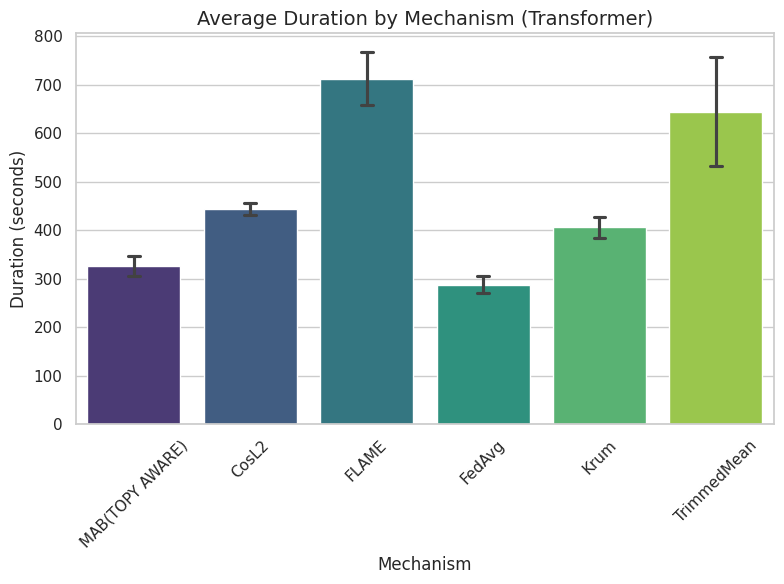

In [ ]:
# ==========================================
# 6. Duration (耗时) 分析与绘图 (固定顺序版)
# ==========================================
# --- 核心修改：复制时直接过滤掉 'MAB(RANDOM TOPY)' ---
df_results2 = df_results[df_results['mechanism'] != 'MAB(RANDOM TOPY)'].copy()

if not df_results2.empty and 'duration_sec' in df_results2.columns:
    print("\n⏱️ 正在生成耗时分析柱状图...")

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 6))

    # --- 获取所有唯一的 mechanism 名称（此时已经没有 MAB(RANDOM TOPY) 了） ---
    all_mechanisms = df_results2['mechanism'].unique().tolist()

    # 定义你想要的顺序：先放 'MAB(TOPY AWARE)'，再放剩下的其他项（按字母排序）
    target_first = 'MAB(TOPY AWARE)'

    if target_first in all_mechanisms:
        # 创建新列表：[target_first] + [除target_first以外的其他项]
        custom_order = [target_first] + sorted([m for m in all_mechanisms if m != target_first])
    else:
        # 如果没找到完全匹配的 'MAB(TOPY AWARE)'，则使用默认排序
        custom_order = sorted(all_mechanisms)

    # 1. 柱状图 (传入 order 参数)
    sns.barplot(
        data=df_results2,
        x='mechanism',
        y='duration_sec',
        order=custom_order,  # 👈 强制固定顺序
        palette='viridis',
        capsize=.1,
        errorbar='sd'
    )

    plt.title('Average Duration by Mechanism (Transformer)', fontsize=14)
    plt.xlabel('Mechanism', fontsize=12)
    plt.ylabel('Duration (seconds)', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show() # 或者 plt.savefig(...)


🔍 开始分析 FedAvg 的 final_asr 和 theo_intensity 相关性 (Kendall Tau) - 包含所有节点...
✅ 发现 18 个 FedAvg 文件，正在提取所有节点数据...

📈 各个 FedAvg 文件的 Kendall Tau 相关性分析结果 (含 P 值):
                                                         File       Topology  Mal_Ratio  Seed  Nodes_Count  Kendall_Tau  P_Value Is_Significant
final_Transformer_random_regular_MR0.3_DR0.2_FedAvg_seed2.csv random_regular     0.3000     2           20       0.0161   0.9221             No
final_Transformer_random_regular_MR0.3_DR0.2_FedAvg_seed1.csv random_regular     0.3000     1           20       0.3677   0.0263            Yes
    final_Transformer_scale_free_MR0.3_DR0.2_FedAvg_seed2.csv     scale_free     0.3000     2           20       0.3787   0.0209            Yes
final_Transformer_random_regular_MR0.2_DR0.2_FedAvg_seed1.csv random_regular     0.2000     1           20       0.5995   0.0002            Yes
final_Transformer_random_regular_MR0.1_DR0.2_FedAvg_seed3.csv random_regular     0.1000     3           20       0.7307   0.00

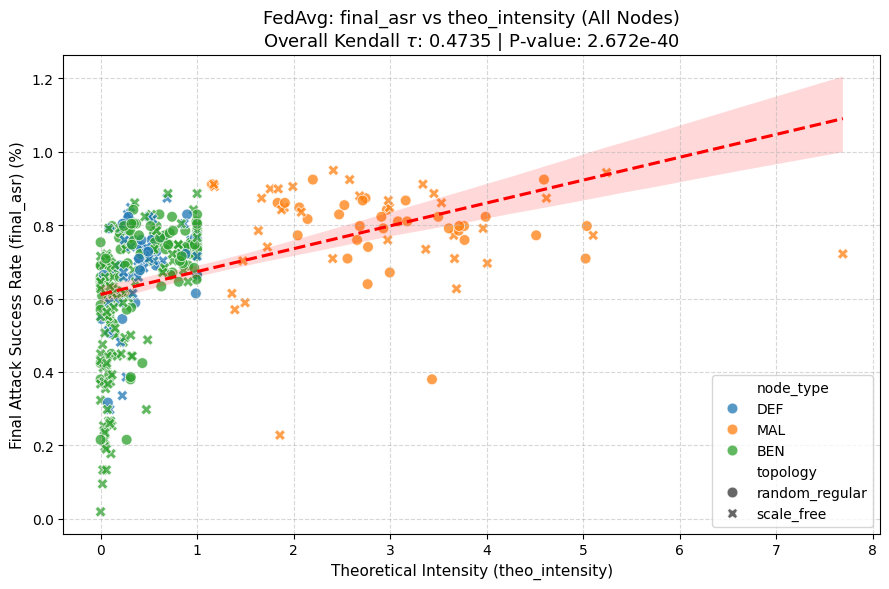

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kendalltau  # 导入用于计算 tau 和 p_value 的函数

# ==========================================
# 6. 分析 FedAvg 文件的 final_asr 与 theo_intensity 的相关性 (Kendall Tau)
# ==========================================
print(f"\n{'='*40}")
print("🔍 开始分析 FedAvg 的 final_asr 和 theo_intensity 相关性 (Kendall Tau) - 包含所有节点...")
print(f"{'='*40}")

# 匹配所有包含 FedAvg 的文件
fedavg_pattern = os.path.join(SAVE_DIR, "final_Transformer*FedAvg*.csv")
fedavg_files = glob.glob(fedavg_pattern)

if not fedavg_files:
    print("\n❌ 未找到任何 FedAvg 相关的 CSV 文件进行相关性分析。")
else:
    print(f"✅ 发现 {len(fedavg_files)} 个 FedAvg 文件，正在提取所有节点数据...\n")

    correlation_results = []
    all_fedavg_nodes = [] # 保存所有文件的数据以供后续汇总绘图

    for f in fedavg_files:
        df = pd.read_csv(f)

        # 1. 保留所有节点（不过滤 MAL 节点）
        df_target = df.copy()

        # 2. 确保目标列为数值类型 (防止字符导致报错)
        df_target['final_asr'] = pd.to_numeric(df_target['final_asr'], errors='coerce')
        df_target['theo_intensity'] = pd.to_numeric(df_target['theo_intensity'], errors='coerce')

        # 3. 去除可能存在的空值
        df_target = df_target.dropna(subset=['final_asr', 'theo_intensity'])

        if len(df_target) > 1: # 至少需要2个点才能算相关性
            # 4. 提取该文件对应的实验参数
            topo = df_target['topology'].iloc[0] if 'topology' in df_target.columns else "Unknown"
            mr = df_target['malicious_ratio'].iloc[0] if 'malicious_ratio' in df_target.columns else "Unknown"
            seed = df_target['seed'].iloc[0] if 'seed' in df_target.columns else "Unknown"

            # 5. 使用 scipy 计算 Kendall Tau 系数和 p 值
            tau, p_value = kendalltau(df_target['final_asr'], df_target['theo_intensity'])

            # 6. 记录结果
            correlation_results.append({
                'File': os.path.basename(f),
                'Topology': topo,
                'Mal_Ratio': mr,
                'Seed': seed,
                'Nodes_Count': len(df_target),
                'Kendall_Tau': tau,
                'P_Value': p_value,
                'Is_Significant': 'Yes' if p_value < 0.05 else 'No'
            })

            all_fedavg_nodes.append(df_target)

    # 7. 显示各个文件单独的相关性结果
    if correlation_results:
        corr_df = pd.DataFrame(correlation_results)
        print("📈 各个 FedAvg 文件的 Kendall Tau 相关性分析结果 (含 P 值):")
        # 优化显示：让数值保留小数点后几位更好看
        pd.options.display.float_format = '{:.4f}'.format
        print(corr_df.to_string(index=False))

        # 8. 综合计算与绘图分析
        combined_df = pd.concat(all_fedavg_nodes, ignore_index=True)

        # 计算整体的 Kendall Tau 相关系数和综合 p 值
        overall_tau, overall_p = kendalltau(combined_df['final_asr'], combined_df['theo_intensity'])

        print("\n" + "-"*40)
        print("🌐 【整体相关性分析汇总】 (包含所有节点)")
        print(f"👉 综合 Kendall Tau (τ): {overall_tau:.4f}")
        print(f"👉 综合 P-Value: {overall_p:.6f}")
        if overall_p < 0.05:
            print("🟢 结论: 具有统计显著性 (P < 0.05)，存在明显的单调相关关系。")
        else:
            print("🔴 结论: 不具有统计显著性 (P >= 0.05)，无法证明存在相关关系。")
        print("-"*40 + "\n")

        # 9. 绘制综合散点图以直观判断相关性强弱和趋势
        plt.figure(figsize=(9, 6))
        # 加入 node_type 作为颜色区分，因为现在包含了 MAL 节点
        sns.scatterplot(data=combined_df, x='theo_intensity', y='final_asr',
                        hue='node_type', style='topology', alpha=0.75, s=60)

        # 添加回归趋势线
        sns.regplot(data=combined_df, x='theo_intensity', y='final_asr',
                    scatter=False, color='red',
                    line_kws={"linestyle":"--", "label": f"Trend Line (Overall $\\tau$={overall_tau:.2f})"})

        plt.title(f"FedAvg: final_asr vs theo_intensity (All Nodes)\nOverall Kendall $\\tau$: {overall_tau:.4f} | P-value: {overall_p:.4g}", fontsize=13)
        plt.xlabel("Theoretical Intensity (theo_intensity)", fontsize=11)
        plt.ylabel("Final Attack Success Rate (final_asr) (%)", fontsize=11)
        plt.legend(loc='best')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
    else:
        print("\n⚠️ 无法计算相关性：未找到足够数量的有效节点数据。")

In [ ]:
#sensitivity
import os
import glob
import pandas as pd
import numpy as np
from itertools import product
from huggingface_hub import HfApi, snapshot_download
from google.colab import userdata

# ==========================================
# 1. Hugging Face 配置 (同步最新敏感性分析数据)
# ==========================================
HF_TOKEN = userdata.get('HF_TOKEN')
REPO_ID = "JONESMITH007/DFL"
LOCAL_ROOT = "./Results_transformer_Comparison"

# 仅保留 sensitivity2 文件夹
REPO_SUBFOLDER_SENS = "FL_Experiments/Results_transformer_Comparison_sensitivity2"
SAVE_DIR_SENS = os.path.join(LOCAL_ROOT, REPO_SUBFOLDER_SENS)

# 确保最新文件被下载
snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    local_dir=LOCAL_ROOT,
    allow_patterns=[f"{REPO_SUBFOLDER_SENS}/final_Transformer*.csv"],
    token=HF_TOKEN,
    force_download=False
)

# ==========================================
# 2. 配置参数 (根据最新命名规则 AT 对齐)
# ==========================================
SEEDS = [1, 2, 3]
TOPO_TYPES = ['scale_free', 'random_regular']
AUDIT_PROBS = [0.8, 0.9]
AGG_PROBS = [0.8, 0.9]
AGG_THRE = [0.4, 0.5] # 对应文件名中的 AT

MR = 0.3

def check_file_transformer(row):
    aup_str = f"{row['AUP']:.1f}" if row['AUP'] in [0.8, 1.0] else str(row['AUP'])
    ap_str = "1" if row['AP'] == 1.0 else str(row['AP'])

    param_str = f"AUP{aup_str}_AP{ap_str}_AT{row['AT']}"
    filename = f"final_Transformer_{row['Topology']}_MR{MR}_{param_str}_seed{row['Seed']}.csv"
    full_path = os.path.join(SAVE_DIR_SENS, filename)
    return os.path.exists(full_path)

# ==========================================
# 3. 执行进度检查
# ==========================================
all_combinations = list(product(TOPO_TYPES, SEEDS, AUDIT_PROBS, AGG_PROBS, AGG_THRE))
tasks_df = pd.DataFrame(all_combinations, columns=['Topology', 'Seed', 'AUP', 'AP', 'AT'])

tasks_df['Is_Completed'] = tasks_df.apply(check_file_transformer, axis=1)

# 汇总展示
progress_summary = tasks_df.groupby(['Topology', 'AUP', 'AP', 'AT']).agg(
    Completed=('Is_Completed', 'sum'),
    Total=('Is_Completed', 'size')
).reset_index()

progress_summary['Progress'] = progress_summary.apply(lambda x: f"{int(x['Completed'])}/{int(x['Total'])}", axis=1)
pivot_status = progress_summary.pivot_table(index=['Topology', 'AUP'], columns=['AP', 'AT'], values='Progress', aggfunc='first')

print("\n📊 实验进度矩阵 (仅 sensitivity2):")
print(pivot_status)

# ==========================================
# 4. 数据加载 (仅读取 sensitivity2)
# ==========================================
list_df = []
def fmt(val_mean, val_std):
    m = val_mean * 100
    s = (0.0 if pd.isna(val_std) else val_std) * 100
    return f"{m:05.2f} ({s:05.2f})"

files_sens = glob.glob(os.path.join(SAVE_DIR_SENS, "final_Transformer*.csv"))
print(f"\n✅ 正在加载 {len(files_sens)} 个实验文件...")

for f in files_sens:
    temp_df = pd.read_csv(f)
    list_df.append(temp_df)

if not list_df:
    print("❌ 未找到任何数据文件，请检查 Hugging Face 同步状态或路径。")
else:
    df_results = pd.concat(list_df, ignore_index=True)

    # 过滤恶意节点并进行分析
    # (确保 CSV 内部存在 agg_thre 或对应列，如果叫 steepness 请在前面改名，这里假定新数据内部已使用 agg_thre)
    df_benign = df_results[df_results['node_type'] != 'MAL'].copy()

    # 注意：如果新 CSV 内部的列名依然是 steepness，请把下面的 agg_thre 换回 steepness
    analysis_df = df_benign.groupby(['audit_prob', 'agg_prob', 'agg_thre']).agg({
        'final_acc': 'mean',
        'final_asr': 'mean'
    }).reset_index()

    print("\n📈 最终敏感性分析汇总:")
    print(analysis_df)

# ==========================================
# 5. 生成分拓扑结构的 LaTeX 敏感性分析表格
# ==========================================
if list_df:
    print("\n📝 正在生成 LaTeX 表格...\n")

    trial_means = df_benign.groupby(
        ['topology', 'audit_prob', 'agg_prob', 'agg_thre', 'seed']
    )[['final_acc', 'final_asr']].mean().reset_index()

    stats = trial_means.groupby(
        ['topology', 'audit_prob', 'agg_prob', 'agg_thre']
    )[['final_acc', 'final_asr']].agg(['mean', 'std']).reset_index()

    stats.columns = [
        '_'.join(col).strip('_') if isinstance(col, tuple) else col
        for col in stats.columns.values
    ]

    def generate_latex_rows(df_subset):
        rows = []
        df_subset = df_subset.sort_values(['audit_prob', 'agg_prob', 'agg_thre'])
        for _, row in df_subset.iterrows():
            aup = f"{row['audit_prob']:.1f}"
            ap = f"{row['agg_prob']:.1f}"
            at = f"{row['agg_thre']:.1f}"
            acc = fmt(row['final_acc_mean'], row['final_acc_std'])
            asr = fmt(row['final_asr_mean'], row['final_asr_std'])
            rows.append(f"{aup} & {ap} & {at} & {acc} & {asr} \\\\")

            # 当 AT=0.5 时绘制横线
            if at == "0.5":
                rows.append(r"\cmidrule(lr){2-5}")
        return "\n".join(rows)

    topologies = stats['topology'].unique()
    table_body = ""
    for topo in topologies:
        topo_label = "Scale-free" if topo == 'scale_free' else "Random-regular"
        subset = stats[stats['topology'] == topo]
        table_body += f"\n\\midrule\n\\multicolumn{{5}}{{l}}{{\\textit{{Topology: {topo_label}}}}} \\\\ \n\\midrule\n"
        table_body += generate_latex_rows(subset)

    latex_final = r"""
\begin{table}[htbp]
    \centering
    \caption{Sensitivity Analysis of MAB Hyperparameters(Transformer on PubMed)}
    \label{tab:mab_sensitivity_split}
    \small
    \begin{tabular}{ccccc}
        \toprule
        \textbf{AUP} & \textbf{AP} & \textbf{AT} & \textbf{ACC (\%)} & \textbf{ASR (\%)} \\
        \midrule
""" + table_body + r"""
        \bottomrule
    \end{tabular}
\end{table}
"""

    latex_final = latex_final.replace(r"\cmidrule(lr){2-5}" + "\n\n\\midrule", r"\midrule")
    latex_final = latex_final.replace(r"\cmidrule(lr){2-5}" + "\n\n\\bottomrule", r"\bottomrule")

    print(latex_final)

Fetching ... files: 0it [00:00, ?it/s]


📊 实验进度矩阵 (仅 sensitivity2):
AP                    0.8000        0.9000       
AT                    0.4000 0.5000 0.4000 0.5000
Topology       AUP                               
random_regular 0.8000    3/3    3/3    3/3    3/3
               0.9000    3/3    3/3    3/3    3/3
scale_free     0.8000    3/3    3/3    3/3    3/3
               0.9000    3/3    3/3    3/3    3/3

✅ 正在加载 48 个实验文件...

📈 最终敏感性分析汇总:
   audit_prob  agg_prob  agg_thre  final_acc  final_asr
0      0.8000    0.8000    0.4000     0.6939     0.1887
1      0.8000    0.8000    0.5000     0.6780     0.1753
2      0.8000    0.9000    0.4000     0.6887     0.1705
3      0.8000    0.9000    0.5000     0.6805     0.2008
4      0.9000    0.8000    0.4000     0.6834     0.1705
5      0.9000    0.8000    0.5000     0.6809     0.1539
6      0.9000    0.9000    0.4000     0.6876     0.1780
7      0.9000    0.9000    0.5000     0.6814     0.1949

📝 正在生成 LaTeX 表格...


\begin{table}[htbp]
    \centering
    \caption{Sensitivity An

In [ ]:
# ==========================================
# 6. 生成分拓扑结构的 LaTeX 敏感性分析表格 (字号优化版)
# ==========================================
print("\n📝 正在生成优化字号后的 LaTeX 表格...\n")

# 1 & 2. 计算均值并扁平化列名 (保持不变)
trial_means = df_benign.groupby(
    ['topology', 'audit_prob', 'agg_prob', 'steepness', 'seed']
)[['final_acc', 'final_asr']].mean().reset_index()

stats = trial_means.groupby(
    ['topology', 'audit_prob', 'agg_prob', 'steepness']
)[['final_acc', 'final_asr']].agg(['mean', 'std']).reset_index()

stats.columns = [
    '_'.join(col).strip('_') if isinstance(col, tuple) else col
    for col in stats.columns.values
]

# 3. 手动构建 LaTeX 行 (保持不变)
def generate_latex_rows(df_subset):
    rows = []
    df_subset = df_subset.sort_values(['audit_prob', 'agg_prob', 'steepness'])
    for _, row in df_subset.iterrows():
        aup = f"{row['audit_prob']:.1f}"
        ap = f"{row['agg_prob']:.1f}"
        st = f"{row['steepness']:.1f}"
        acc = fmt(row['final_acc_mean'], row['final_acc_std'])
        asr = fmt(row['final_asr_mean'], row['final_asr_std'])
        rows.append(f"{aup} & {ap} & {st} & {acc} & {asr} \\\\")
        if st == "2.0":
            rows.append(r"\cmidrule(lr){2-5}")
    return "\n".join(rows)

# 4. 组装 Table Body (保持不变)
topologies = stats['topology'].unique()
table_body = ""
for topo in topologies:
    topo_label = "Scale-free" if topo == 'scale_free' else "Random-regular"
    subset = stats[stats['topology'] == topo]
    table_body += f"\n\\midrule\n\\multicolumn{{5}}{{l}}{{\\textit{{Topology: {topo_label}}}}} \\\\ \n\\midrule\n"
    table_body += generate_latex_rows(subset)

# 5. 🌟 核心修改：组合 Table 环境 (移除 resizebox，加入 \small)
# 同时移除了 tabular 中的竖线 | 以符合学术规范
latex_final = r"""
\begin{table}[htbp]
    \centering
    \caption{Sensitivity Analysis of MAB Hyperparameters (ACC and ASR \%)}
    \label{tab:mab_sensitivity_split}
    \small
    \begin{tabular}{ccccc}
        \toprule
        \textbf{AUP} & \textbf{AP} & \textbf{ST} & \textbf{ACC (\%)} & \textbf{ASR (\%)} \\
        \midrule
""" + table_body + r"""
        \bottomrule
    \end{tabular}
\end{table}
"""

# 清理重复符号
latex_final = latex_final.replace(r"\cmidrule(lr){2-5}" + "\n\n\\midrule", r"\midrule")
latex_final = latex_final.replace(r"\cmidrule(lr){2-5}" + "\n\n\\bottomrule", r"\bottomrule")

print(latex_final)


📝 正在生成优化字号后的 LaTeX 表格...


\begin{table}[htbp]
    \centering
    \caption{Sensitivity Analysis of MAB Hyperparameters (ACC and ASR \%)}
    \label{tab:mab_sensitivity_split}
    \small  
    \begin{tabular}{ccccc} 
        \toprule
        \textbf{AUP} & \textbf{AP} & \textbf{ST} & \textbf{ACC (\%)} & \textbf{ASR (\%)} \\
        \midrule

\midrule
\multicolumn{5}{l}{\textit{Topology: Random-regular}} \\ 
\midrule
0.8 & 0.8 & 0.5 & 00.69 (00.01) & 00.18 (00.02) \\
0.8 & 0.8 & 2.0 & 00.69 (00.01) & 00.20 (00.03) \\
\cmidrule(lr){2-5}
0.8 & 1.0 & 0.5 & 00.70 (00.01) & 00.15 (00.06) \\
0.8 & 1.0 & 2.0 & 00.70 (00.01) & 00.15 (00.01) \\
\cmidrule(lr){2-5}
0.9 & 0.9 & 1.0 & 00.69 (00.00) & 00.19 (00.05) \\
1.0 & 0.8 & 0.5 & 00.70 (00.01) & 00.22 (00.05) \\
1.0 & 0.8 & 2.0 & 00.67 (00.01) & 00.14 (00.07) \\
\cmidrule(lr){2-5}
1.0 & 1.0 & 0.5 & 00.70 (00.01) & 00.16 (00.03) \\
1.0 & 1.0 & 2.0 & 00.67 (00.01) & 00.18 (00.01) \\
\cmidrule(lr){2-5}
\midrule
\multicolumn{5}{l}{\textit{Topology:

In [ ]:
benign_comparison

final_acc                               final_asr            \
malicious_ratio       0.1       0.2       0.3       0.4       0.1       0.2   
mechanism                                                                     
CosL2            0.879085  0.875525  0.838235  0.842647  0.128638  0.134726   
FLAME            0.808590  0.806197  0.791176  0.789216  0.286234  0.302243   
FedAvg           0.878151  0.863358  0.786134  0.661765  0.258598  0.489149   
Krum             0.884314  0.870273  0.830252  0.789706  0.234788  0.288053   
MAB              0.921024  0.904412  0.875210  0.841176  0.046737  0.154868   

                                     
malicious_ratio       0.3       0.4  
mechanism                            
CosL2            0.222449  0.217609  
FLAME            0.328997  0.327083  
FedAvg           0.631378  0.804712  
Krum             0.437372  0.707292  
MAB              0.307483  0.403720

In [ ]:
# ==========================================
# 6. 生成期刊级别的 LaTeX 表格 (Mean (Std))
# ==========================================
print("\n📝 正在生成 LaTeX 表格代码...\n")

# 确保 df_results 中包含 'seed' 和 'topology' 列。
# 如果加载 CSV 时没有自动带入，你需要确保原始 CSV 包含这些字段。

# 过滤良性节点
df_benign = df_results[df_results['Role'] == 'Benign'].copy()
df_benign = df_results[df_results['malicious_ratio'] <0.4].copy()
# 第一步：计算每个试验 (每个 seed) 内，良性节点的平均表现
trial_means = df_benign.groupby(
    ['topology', 'mechanism', 'malicious_ratio', 'seed']
)[['final_acc', 'final_asr']].mean().reset_index()

# 第二步：计算跨不同 seed 的均值 (mean) 和标准差 (std)
stats = trial_means.groupby(
    ['topology', 'mechanism', 'malicious_ratio']
)[['final_acc', 'final_asr']].agg(['mean', 'std']).reset_index()

# 辅助函数：将 mean 和 std 格式化为 "Mean (Std)" 字符串
# 如果你的数据是 0.85 这种小数，可以将 `m` 和 `s` 乘以 100 变成百分比形式。
# 这里的代码假设你的数据已经是 0~100 的数值，并保留两位小数。
def format_mean_std(row, metric):
    m = row[(metric, 'mean')]
    s = row[(metric, 'std')]
    return f"{m:.2f} ({s:.2f})"

# 应用格式化
stats['ACC'] = stats.apply(lambda r: format_mean_std(r, 'final_acc'), axis=1)
stats['ASR'] = stats.apply(lambda r: format_mean_std(r, 'final_asr'), axis=1)

# 清理表头 (去掉 multi-level 索引以便于后续透视)
clean_stats = stats[['topology', 'mechanism', 'malicious_ratio', 'ACC', 'ASR']].copy()
# 因为 pandas 版本不同，提取多级索引列后可能会带元组列名，这里直接重命名
clean_stats.columns = ['topology', 'mechanism', 'malicious_ratio', 'ACC', 'ASR']

# --- 选择要展示的拓扑结构 (例如 'scale_free') ---
target_topo = 'scale_free'   # 你可以改成 'random_regular' 跑两次，生成两个表'scale_free'
df_topo = clean_stats[clean_stats['topology'] == target_topo].drop(columns=['topology'])

# 创建数据透视表，行是 mechanism，列是 malicious_ratio
pivot_table = df_topo.pivot(index='mechanism', columns='malicious_ratio', values=['ACC', 'ASR'])

# 交换列的层级并排序，使得相同 malicious_ratio 下的 ACC 和 ASR 挨在一起
pivot_table = pivot_table.swaplevel(0, 1, axis=1).sort_index(axis=1, level=0)

# 生成 LaTeX 格式 (引入 booktabs 以支持高质量表格线条)
# 注意：旧版 pandas 可能用 .to_latex()，新版建议使用 style.to_latex()
try:
    latex_str = pivot_table.style.format(escape="latex").to_latex(
        hrules=True,
        multicol_align="c",
        caption=f"Performance of Benign Clients under Different Defense Mechanisms (Topology: {target_topo})",
        label=f"tab:results_{target_topo}"
    )
except AttributeError:
    # 兼容老版本 Pandas
    latex_str = pivot_table.to_latex(
        multicolumn=True,
        multicolumn_format='c',
        booktabs=True,
        escape=False,
        caption=f"Performance of Benign Clients under Different Defense Mechanisms (Topology: {target_topo})",
        label=f"tab:results_{target_topo}"
    )

print(latex_str)


📝 正在生成 LaTeX 表格代码...

\begin{table}
\caption{Performance of Benign Clients under Different Defense Mechanisms (Topology: scale_free)}
\label{tab:results_scale_free}
\begin{tabular}{lllllll}
\toprule
malicious_ratio & \multicolumn{2}{c}{0.100000} & \multicolumn{2}{c}{0.200000} & \multicolumn{2}{c}{0.300000} \\
 & ACC & ASR & ACC & ASR & ACC & ASR \\
mechanism &  &  &  &  &  &  \\
\midrule
CosL2 & 0.83 (0.04) & 0.17 (0.06) & 0.82 (0.07) & 0.24 (0.11) & 0.78 (0.07) & 0.33 (0.11) \\
FLAME & 0.77 (0.05) & 0.22 (0.05) & 0.77 (0.06) & 0.28 (0.05) & 0.75 (0.05) & 0.32 (0.07) \\
FedAvg & 0.72 (0.07) & 0.85 (0.12) & 0.54 (0.12) & 0.95 (0.03) & 0.46 (0.09) & 0.96 (0.04) \\
Krum & 0.85 (0.06) & 0.20 (0.09) & 0.81 (0.07) & 0.41 (0.19) & 0.76 (0.09) & 0.69 (0.22) \\
MAB & 0.83 (0.04) & 0.32 (0.19) & 0.77 (0.07) & 0.50 (0.13) & 0.76 (0.08) & 0.56 (0.19) \\
TrimmedMean & 0.73 (0.08) & 0.79 (0.26) & 0.77 (0.05) & 0.62 (0.17) & 0.77 (0.05) & 0.62 (0.24) \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
df_topo

,mechanism,malicious_ratio,ACC,ASR
18,CosL2,0.1,0.83 (0.04),0.17 (0.06)
19,CosL2,0.2,0.82 (0.07),0.24 (0.11)
20,CosL2,0.3,0.78 (0.07),0.33 (0.11)
21,FLAME,0.1,0.77 (0.05),0.22 (0.05)
22,FLAME,0.2,0.77 (0.06),0.28 (0.05)
23,FLAME,0.3,0.75 (0.05),0.32 (0.07)
24,FedAvg,0.1,0.72 (0.07),0.85 (0.12)
25,FedAvg,0.2,0.54 (0.12),0.95 (0.03)
26,FedAvg,0.3,0.46 (0.09),0.96 (0.04)
27,Krum,0.1,0.85 (0.06),0.20 (0.09)
